<a href="https://colab.research.google.com/github/Gabriel-Orlandi-Portes/Analise-Brasileiro2024/blob/main/analise_brasileirao_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análise Campeonato Brasileiro Série A 2024**

Este projeto tem como objetivo realizar uma análise exploratória dos dados do Campeonato Brasileiro Série A de 2024. Os dados foram obtidos por meio da plataforma Kaggle, através do dataset disponível no link: https://www.kaggle.com/datasets/fabioschirmann/brasileiro-2024-srie-a-dataset. O conjunto de dados contém informações sobre as partidas do campeonato, incluindo times envolvidos, placar, público presente e estádio das partidas.

In [ ]:
## Importação das bibliotecas.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
## Carregando a tabela ...

df = pd.read_csv('Brasileiro2024.csv', sep = ',', header=None)

In [ ]:
## Como o DataSet não possuía colunas, foi necessário definir o nome destas.

df.columns = [
    'Data',
    'Hora',
    'Mandante',
    'Placar',
    'Visitante',
    'Publico',
    'Estadio'
]

In [ ]:
## Visualização inicial dos dados.

df.head(10)

,Data,Hora,Mandante,Placar,Visitante,Publico,Estadio
0,2024-04-13,18:30,Criciúma,1–1,Juventude,"12,804",Estádio Heriberto Hülse
1,2024-04-13,18:30,Internacional,2–1,Bahia,"19,103",Estádio José Pinheiro Borba
2,2024-04-14,16:00,Ath Paranaense,4–0,Cuiabá,"21,388",Ligga Arena
3,2024-04-14,16:00,Vasco da Gama,2–1,Grêmio,"17,722",Estádio Club de Regatas Vasco da Gama
4,2024-04-14,16:00,Corinthians,0–0,Atlético Mineiro,"44,285",Neo Química Arena
5,2024-04-14,16:00,Atl Goianiense,1–2,Flamengo,"31,617",Estádio do Governo do Estado de Goiás
6,2024-04-14,17:00,Cruzeiro,3–2,Botafogo (RJ),"20,701",Estádio Governador Magalhães Pinto
7,2024-04-14,18:30,Vitória,0–1,Palmeiras,"30,644",Estádio Manoel Barradas
8,2024-04-13,21:00,Fluminense,2–2,RB Bragantino,"17,645",Estadio Jornalista Mário Filho
9,2024-04-13,21:00,São Paulo,1–2,Fortaleza,"35,055",Estádio do Morumbi


In [ ]:
## Quantidade de linhas e colunas.

df.shape

(380, 7)

In [ ]:
## Variáveis e dados

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Data       380 non-null    object
 1   Hora       380 non-null    object
 2   Mandante   380 non-null    object
 3   Placar     380 non-null    object
 4   Visitante  380 non-null    object
 5   Publico    376 non-null    object
 6   Estadio    380 non-null    object
dtypes: object(7)
memory usage: 20.9+ KB


A variável "Publico" foi inicialmente interpretada pelo Pandas como texto (object), pois os valores possuíam separador de milhar utilizando vírgula. Foi realizada a conversão para um formato numérico para possibilitar análises estatísticas.

In [ ]:
df['Publico'] = (
    df['Publico']
    .str.replace(',', '')
    .fillna(0)
    .astype(int)
)

In [ ]:
## Conferindo se a variável publico virou int64

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Data       380 non-null    object
 1   Hora       380 non-null    object
 2   Mandante   380 non-null    object
 3   Placar     380 non-null    object
 4   Visitante  380 non-null    object
 5   Publico    380 non-null    int64 
 6   Estadio    380 non-null    object
dtypes: int64(1), object(6)
memory usage: 20.9+ KB


In [ ]:
## Como a variável Publico é quantitativa, abaixo são apresentados os menores e maiores valores encontrados na coluna.
## Observação: valores iguais a 0 podem representar ausência de informação no dataset, não necessariamente um jogo sem presença de torcedores.

print('Menor público:', df['Publico'].min())
print('Maior público:', df['Publico'].max())

Menor público: 0
Maior público: 67113


# **Dicionário de Dados**

### Informações das variáveis:

Quantidade de dados: 380

Quantidade de colunas: 7


**0 - Data**

Tipo: object

Descrição: Data em que a partida foi realizada.

Valores: Datas referentes aos jogos do Campeonato Brasileiro Série A 2024.


**1 - Hora**

Tipo: object

Descrição: Horário de início da partida.

Valores: Exemplos: 16:00, 18:30, 21:00.


**2 - Mandante**

Tipo: object

Descrição: Equipe que disputou a partida como mandante (time da casa).

Valores: Exemplos: Criciúma, Internacional, Flamengo, Palmeiras.


**3 - Placar**

Tipo: object

Descrição: Resultado final da partida.

Valores: Exemplos: 1-0, 2-1, 0-0.


**4 - Visitante**

Tipo: object

Descrição: Equipe que disputou a partida como visitante.

Valores: Exemplos: Juventude, Bahia, Corinthians.


**5 - Publico**

Tipo: int64

Descrição: Quantidade de torcedores presentes no estádio durante a partida.

Valores: Varia entre 0 e 67113 espectadores. Valores iguais a 0 podem representar ausência de informação no dataset.


**6 - Estadio**

Tipo: object

Descrição: Estádio onde a partida foi realizada.

Valores: Exemplos: Estádio do Morumbi, Maracanã, Allianz Parque.


**Observação:**

 A variável Publico passou por tratamento, pois inicialmente foi identificada pelo Pandas como object devido ao formato dos valores com separador de milhar. Após a limpeza, foi convertida para o tipo inteiro para possibilitar análises quantitativas.

# **Análise Com Uma Variável**

## **Pergunta:**
### **Quais foram os placares mais frequentes nas partidas do Campeonato Brasileiro Série A 2024?**


---


### Para responder essa pergunta, foi analisada a frequência dos resultados das partidas. A variável "Placar" apresenta o resultado final dos jogos, permitindo identificar quais placares aconteceram mais vezes durante o campeonato.

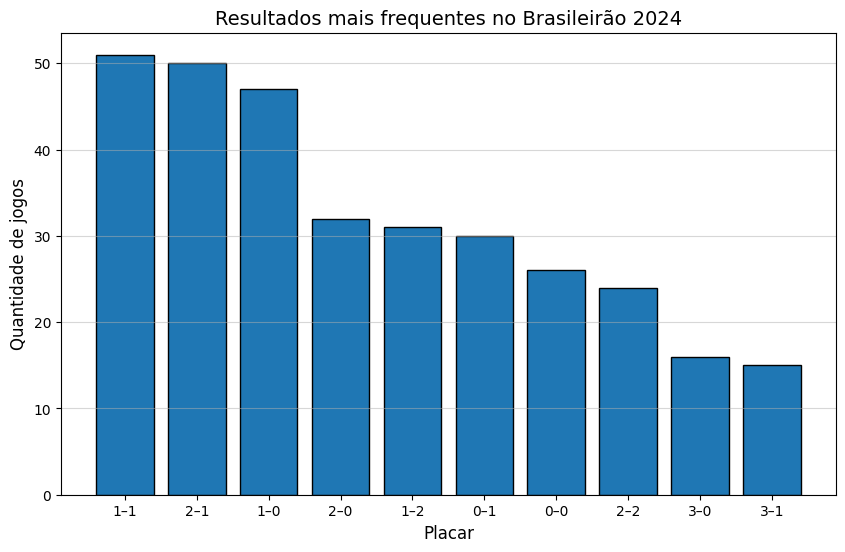

In [ ]:
placares = df['Placar'].value_counts().head(10)

plt.figure(figsize=(10,6))

plt.bar(
    placares.index,
    placares.values,
    edgecolor='black'
)

plt.title('Resultados mais frequentes no Brasileirão 2024', fontsize=14)
plt.xlabel('Placar', fontsize=12)
plt.ylabel('Quantidade de jogos', fontsize=12)


plt.grid(axis='y', alpha=0.5)

plt.show()

### **Conclusão:**

### O placar mais frequente foi 1-0, seguido por 1-1 e 2-1. Isso sugere que a maioria das partidas do Brasileirão 2024 foi decidida por margens pequenas de gols.

# **Análise Com Duas Variáveis**

## **Pergunta:**
### **Quais times tiveram as maiores médias de público como mandantes no Campeonato Brasileiro Série A 2024?**


---


### Para responder essa pergunta, foram analisadas as variáveis Mandante e Publico. Foi calculada a média de público dos jogos de cada equipe atuando em casa, permitindo comparar quais clubes tiveram maior presença de torcedores em seus estádios.

In [ ]:
## Calcula a média de cada time

media_publico = (
    df.groupby('Mandante')['Publico']
    .mean()
    .sort_values(ascending=False)
)

media_publico

,Publico
Mandante,
Flamengo,47599.894737
Corinthians,43800.578947
São Paulo,36248.315789
Ath Paranaense,31922.631579
Fortaleza,31053.947368
Bahia,30731.842105
Palmeiras,29786.842105
Internacional,28447.000000
Fluminense,28253.947368


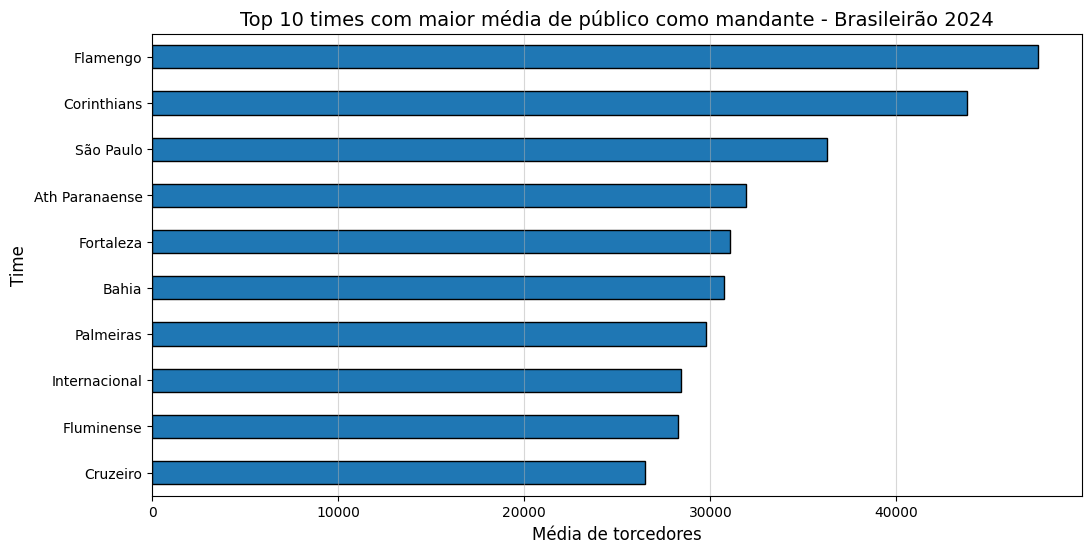

In [ ]:
media_publico_top10 = media_publico.head(10)

plt.figure(figsize=(12,6))

media_publico_top10.sort_values().plot(
    kind='barh',
    edgecolor='black'
)

plt.title('Top 10 times com maior média de público como mandante - Brasileirão 2024', fontsize=14)
plt.xlabel('Média de torcedores', fontsize=12)
plt.ylabel('Time', fontsize=12)

plt.grid(axis='x', alpha=0.5)

plt.show()

### **Conclusão:**

### Flamengo apresentou a maior média de público, seguido por Corinthians e São Paulo. Isso demonstra a força de suas torcidas e a alta ocupação dos estádios ao longo do campeonato.

# **Conclusão geral**



---

### A análise realizada permitiu identificar características das partidas do Campeonato Brasileiro Série A 2024, observando a distribuição do público e a relação entre clubes mandantes e presença de torcedores. Os resultados mostram diferenças de comportamento entre as equipes e ajudam a compreender padrões relacionados à audiência dos jogos.

